Meta-SIR = 保留 MIR mobility，但无 awareness 迁移增强传播


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================================
# 纯 SIR 元种群模型（MIR 机制，无信息层）
# 修改：移动网络生成使用 nx.erdos_renyi_graph 的 seed 参数，避免全局种子干扰
# ============================================================================

def generate_mobility_network(N, avg_deg_mob, seed=None):
    """
    生成移动网络邻接矩阵 Wmob，并构造移动概率矩阵 R。
    每行均分给邻居，孤立节点只能留在本地。
    """
    p_mob = avg_deg_mob / (N-1) if N > 1 else 0
    p_mob = min(p_mob, 1.0)
    G_mob = nx.erdos_renyi_graph(N, p_mob, seed=seed, directed=False)
    Wmob = nx.to_numpy_array(G_mob, dtype=float)
    
    R = np.zeros((N, N))
    for i in range(N):
        neighbors = np.where(Wmob[i] > 0)[0]
        deg = len(neighbors)
        if deg > 0:
            R[i, neighbors] = 1.0 / deg
        else:
            R[i, i] = 1.0   # 孤立节点：只能留在本地
    return R

def compute_flows(n, g, R):
    N = len(n)
    flow = np.zeros((N, N))
    for j in range(N):
        stay = (1 - g) * n[j]
        move_out = g * n[j]
        for i in range(N):
            if i == j:
                flow[j, i] = stay + move_out * R[j, i]
            else:
                flow[j, i] = move_out * R[j, i]
    return flow

def compute_patch_infection_risk(flow, pI, beta):
    N = flow.shape[0]
    N_i = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(N):
            f = flow[j, i]
            if f > 0:
                prod *= (1 - beta * pI[j]) ** f
        N_i[i] = 1 - prod
    return N_i

def compute_individual_infection_risk(N_i, g, R):
    Q = (1 - g) * N_i + g * np.dot(R, N_i)
    return Q

def update_states(states, Q, mu):
    S, I, R = states.T
    new_S = S * (1 - Q)
    new_I = I * (1 - mu) + S * Q
    new_R = R + I * mu
    new_states = np.vstack([new_S, new_I, new_R]).T
    row_sum = new_states.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    new_states /= row_sum
    return new_states

def single_run(Time, N, params, seed_mob):
    """
    单次仿真运行，允许指定移动网络随机种子。
    """
    beta = params["beta"]
    mu   = params["mu"]
    g    = params["g"]
    avg_deg_mob = params["avg_deg_mob"]

    # 生成移动矩阵（使用独立种子）
    R = generate_mobility_network(N, avg_deg_mob, seed=seed_mob)

    # 初始常住人口
    n = np.full(N, 200.0)

    # 初始状态（确定性：S=0.99, I=0.01, R=0）
    states = np.zeros((N, 3))
    states[:, 0] = 0.99   # S
    states[:, 1] = 0.01   # I
    states[:, 2] = 0.00   # R

    history = np.zeros((Time, 3))

    for t in range(Time):
        global_state = np.sum(states * n[:, None], axis=0) / np.sum(n)
        history[t] = global_state

        flow = compute_flows(n, g, R)
        pI = states[:, 1]
        N_i = compute_patch_infection_risk(flow, pI, beta)
        Q = compute_individual_infection_risk(N_i, g, R)
        states = update_states(states, Q, mu)

    return history


# ============================================================================
# 多次重复实验主程序
# ============================================================================
if __name__ == "__main__":
    # -------------------- 固定参数设置 --------------------
    Time = 150
    N = 15               # 子种群数量
    num_simulations = 20   # 重复实验次数

    params = {
        "beta": 0.003,       # 感染率
        "mu": 0.1,          # 恢复率
        "g": 0.2,          # 移动概率
        "avg_deg_mob": 10, # 移动网络平均度
    }

    # -------------------- 存储所有仿真结果 --------------------
    all_history = np.zeros((num_simulations, Time, 3))  # (重复次数, 时间, 3状态)

    # -------------------- 循环重复实验 --------------------
    base_seed = 42
    for sim in range(num_simulations):
        # 每次实验使用不同的移动网络种子
        seed_mob = base_seed + sim
        history = single_run(Time, N, params, seed_mob)
        all_history[sim] = history

        if (sim + 1) % 20 == 0:
            print(f"已完成 {sim + 1} / {num_simulations} 次仿真")

    # -------------------- 统计结果 --------------------
    mean_history = all_history.mean(axis=0)          # (Time, 3)

    # -------------------- 保存 CSV 文件 --------------------
    df_mean = pd.DataFrame(mean_history, columns=["S", "I", "R"])


    df_mean.to_csv("MIR_SIR_mean.csv", index=False)


    print("200 次重复实验完成，统计结果已保存。")


已完成 20 / 20 次仿真
200 次重复实验完成，统计结果已保存。


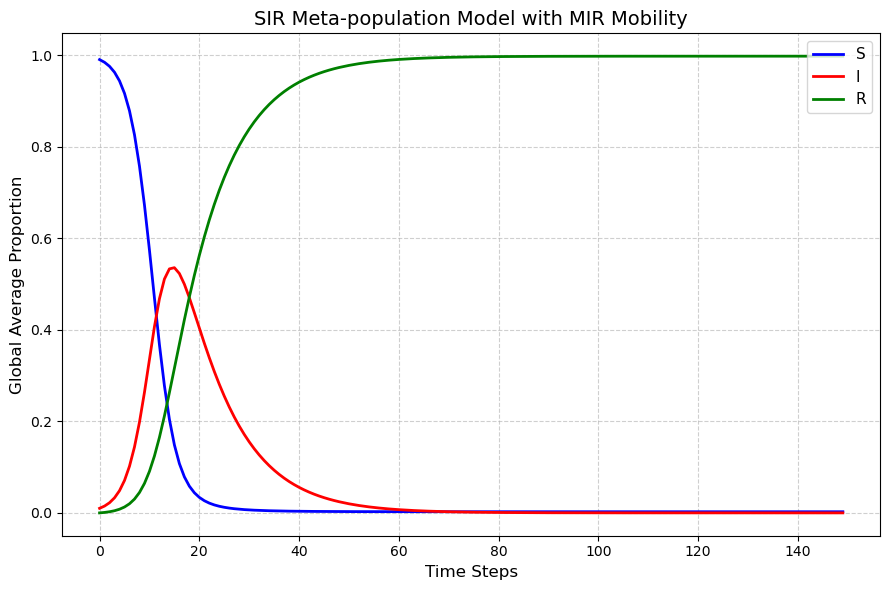

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. 读取 SIR 模型的输出 CSV 文件
# ============================================
file_name = "MIR_SIR_mean.csv"   # 根据实际文件名修改
df = pd.read_csv(file_name)

# ============================================
# 2. 设置三状态的颜色映射（沿用统一风格）
# ============================================
state_colors = {
    'S': 'blue',      # 易感
    'I': 'red',       # 感染
    'R': 'green'      # 康复
}
state_labels = ['S', 'I', 'R']   # 必须与 df 列顺序一致

# ============================================
# 3. 创建画布并绘制各状态曲线
# ============================================
plt.figure(figsize=(9, 6))

for i, label in enumerate(state_labels):
    plt.plot(
        df.index,                 # 时间步（0 ~ Time-1）
        df[label],               # 该状态的全局平均比例
        label=label,
        color=state_colors[label],
        linewidth=2
    )

# ============================================
# 4. 图表装饰（模板风格）
# ============================================
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Global Average Proportion', fontsize=12)
plt.title('SIR Meta-population Model with MIR Mobility', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片（可选）
# plt.savefig('SIR_MIR_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()